# Notebook 3 — Model Training

**Purpose:** Train the XGBoost multi-class classifier and evaluate it thoroughly. XGBoost is chosen because the dissertation literature (Al-Barhami et al., 2026) identifies it as the top-performing model for this tabular CI/CD data. We compare accuracy to the 95.9% benchmark and produce classification report, confusion matrix, feature importance, and learning curves. The trained model is saved for Notebook 4 (SHAP) and the dashboard.

In [40]:
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.model_selection import cross_val_score, learning_curve
import xgboost as xgb

# Suppress known warnings (use_label_encoder deprecated; joblib worker timeout in long runs)
warnings.filterwarnings("ignore", message=".*use_label_encoder.*")
warnings.filterwarnings("ignore", message=".*worker stopped.*")

ROOT = Path("../").resolve()
sys.path.insert(0, str(ROOT))
from src.preprocessing import prepare_for_training
from src.paths import MODELS_DIR, REPORTS_FIGURES

# XGBoost GPU = NVIDIA + CUDA only. On Mac M1/M2/M3 (Apple Silicon) use CPU — no CUDA support.
USE_GPU = False  # Keep False on Mac M1 Pro; M1 CPU is fast. True only for NVIDIA GPU.
xgb_device_kw = {"device": "cuda"} if USE_GPU else {}

REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")

### Load processed data

Load the train/validation/test splits and encoders saved by Notebook 2.

In [41]:
print("Loading processed data from disk...")
X_train, X_val, X_test, y_train, y_val, y_test, feature_list, class_names, _ = prepare_for_training()
print("Features:", feature_list)
print("Classes:", class_names)
print("Train size:", len(X_train), "| Val size:", len(X_val), "| Test size:", len(X_test))

Loading processed data from disk...
Features: ['build_duration_sec', 'commits_per_build', 'loc_changed', 'hour_of_day', 'day_of_week', 'is_weekend', 'test_pass_rate', 'previous_build_failed', 'gh_lang_enc']
Classes: ['canceled', 'errored', 'failed', 'passed']
Train size: 2717392 | Val size: 582298 | Test size: 582299


### Class imbalance

TravisTorrent has significant class imbalance (e.g. "passed" far outnumbers "failed" and "errored"). We address this by setting **sample weights** in XGBoost so that the model pays more attention to minority classes. An alternative would be oversampling (e.g. SMOTE); we use weights because it is simple, does not duplicate data, and XGBoost supports it natively.

In [42]:
from sklearn.utils.class_weight import compute_sample_weight
print("Computing sample weights for class imbalance...")
sample_weights_train = compute_sample_weight(class_weight="balanced", y=y_train)
sample_weights_val = compute_sample_weight(class_weight="balanced", y=y_val)
print("Sample weights computed (balanced).")
print("Class distribution (train):", dict(zip(*np.unique(y_train, return_counts=True))))

Computing sample weights for class imbalance...
Sample weights computed (balanced).
Class distribution (train): {np.int64(0): np.int64(28134), np.int64(1): np.int64(195638), np.int64(2): np.int64(526072), np.int64(3): np.int64(1967548)}


### Baseline model

Train a baseline XGBoost with default or simple parameters to establish a reference point before hyperparameter tuning.

In [43]:
print("Training baseline XGBoost (100 trees, max_depth=6)...")
baseline = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softprob",
    num_class=len(class_names),
    random_state=42,
    eval_metric="mlogloss",
    **xgb_device_kw,
)
baseline.fit(X_train, y_train, sample_weight=sample_weights_train, verbose=1)
acc_baseline = accuracy_score(y_val, baseline.predict(X_val))
print(f"Baseline validation accuracy: {acc_baseline:.4f}")
print("Baseline done.")

Training baseline XGBoost (100 trees, max_depth=6)...
Baseline validation accuracy: 0.6779
Baseline done.


### Hyperparameter search (tuned for 95%+ accuracy)

We use **RandomizedSearchCV** over an expanded space (n_estimators up to 800, max_depth up to 12, min_child_weight, gamma, learning_rate, subsample, colsample_bytree, regularization) with 72 candidates. Then we retrain with **early stopping** and up to 800 trees for better generalization and higher accuracy.

In [44]:
from sklearn.model_selection import RandomizedSearchCV

N_ITER, CV_FOLDS = 96, 3
total_fits = N_ITER * CV_FOLDS
print(f"Hyperparameter search: {N_ITER} candidates × {CV_FOLDS} folds = {total_fits} fits (n_jobs=-1).")
print("This may take 30–90+ minutes. Progress below (verbose=2)...")

# Expanded search for 95%: more regularization options, shallower trees to reduce overfitting
param_dist = {
    "n_estimators": [500, 700, 800, 1000],
    "max_depth": [6, 8, 10, 12],
    "learning_rate": [0.02, 0.04, 0.06, 0.08, 0.1],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.2, 0.3],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_alpha": [0.1, 0.5, 1.0, 2.0],
    "reg_lambda": [0.5, 1.0, 2.0, 3.0],
}
search = RandomizedSearchCV(
    xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=len(class_names),
        random_state=42,
        eval_metric="mlogloss",
        **xgb_device_kw,
    ),
    param_dist,
    n_iter=N_ITER,
    cv=CV_FOLDS,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
    random_state=42,
)
search.fit(X_train, y_train, sample_weight=sample_weights_train)
print("Hyperparameter search complete.")
print("Best params:", search.best_params_)
print("Best CV score:", search.best_score_)
best_params = search.best_params_.copy()

Hyperparameter search: 96 candidates × 3 folds = 288 fits (n_jobs=-1).
This may take 30–90+ minutes. Progress below (verbose=2)...
Fitting 3 folds for each of 96 candidates, totalling 288 fits
[CV] END colsample_bytree=0.85, gamma=0.3, learning_rate=0.1, max_depth=10, min_child_weight=7, n_estimators=500, reg_alpha=2.0, reg_lambda=0.5, subsample=1.0; total time= 5.2min
[CV] END colsample_bytree=0.85, gamma=0.3, learning_rate=0.1, max_depth=10, min_child_weight=7, n_estimators=500, reg_alpha=2.0, reg_lambda=0.5, subsample=1.0; total time= 5.4min
[CV] END colsample_bytree=0.85, gamma=0.3, learning_rate=0.1, max_depth=10, min_child_weight=7, n_estimators=500, reg_alpha=2.0, reg_lambda=0.5, subsample=1.0; total time= 5.4min
[CV] END colsample_bytree=0.85, gamma=0.2, learning_rate=0.08, max_depth=12, min_child_weight=1, n_estimators=500, reg_alpha=0.5, reg_lambda=0.5, subsample=1.0; total time= 7.9min
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.06, max_depth=12, min_child_weight

### Final model with early stopping

Retrain with the best hyperparameters and a larger number of rounds; use early stopping on the validation set to avoid overfitting and maximize accuracy.

In [45]:
# Train final model with early stopping (more rounds for 95% push)
# XGBoost 2.x: early_stopping_rounds goes in the constructor, not in fit()
n_est = max(best_params.get("n_estimators", 500), 800)
print(f"Training final model: up to {n_est} trees, early_stopping_rounds=25 (verbose=1)...")
best_params_final = {k: v for k, v in best_params.items() if k != "n_estimators"}
best_model = xgb.XGBClassifier(
    n_estimators=n_est,
    objective="multi:softprob",
    num_class=len(class_names),
    random_state=42,
    eval_metric="mlogloss",
    early_stopping_rounds=25,
    **best_params_final,
    **xgb_device_kw,
)
best_model.fit(
    X_train, y_train,
    sample_weight=sample_weights_train,
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[sample_weights_val],
    verbose=1,
)
best_iter = getattr(best_model, "best_iteration", None) or getattr(best_model, "best_ntree_limit", n_est)
val_acc = accuracy_score(y_val, best_model.predict(X_val))
print(f"Best iteration: {best_iter} (early stopping)")
print(f"Validation accuracy: {val_acc:.4f}")
print("Final model training complete.")

Training final model: up to 800 trees, early_stopping_rounds=25 (verbose=1)...
[0]	validation_0-mlogloss:1.35947
[1]	validation_0-mlogloss:1.33605
[2]	validation_0-mlogloss:1.31202
[3]	validation_0-mlogloss:1.29032
[4]	validation_0-mlogloss:1.26625
[5]	validation_0-mlogloss:1.24519
[6]	validation_0-mlogloss:1.22621
[7]	validation_0-mlogloss:1.20853
[8]	validation_0-mlogloss:1.19124
[9]	validation_0-mlogloss:1.17747
[10]	validation_0-mlogloss:1.16336
[11]	validation_0-mlogloss:1.14930
[12]	validation_0-mlogloss:1.13648
[13]	validation_0-mlogloss:1.12860
[14]	validation_0-mlogloss:1.11701
[15]	validation_0-mlogloss:1.10802
[16]	validation_0-mlogloss:1.09838
[17]	validation_0-mlogloss:1.08771
[18]	validation_0-mlogloss:1.07888
[19]	validation_0-mlogloss:1.07068
[20]	validation_0-mlogloss:1.06358
[21]	validation_0-mlogloss:1.05522
[22]	validation_0-mlogloss:1.04791
[23]	validation_0-mlogloss:1.04068
[24]	validation_0-mlogloss:1.03461
[25]	validation_0-mlogloss:1.02752
[26]	validation_0-mlo

### Test set evaluation

Evaluate the best model on the held-out test set. We report accuracy (with comparison to the 95.9% benchmark from Al-Barhami et al., 2026), full classification report, and confusion matrix (counts and percentages).

In [46]:
print("Evaluating on held-out test set...")
y_pred = best_model.predict(X_test)
acc_test = accuracy_score(y_test, y_pred)
f1_test = f1_score(y_test, y_pred, average="weighted")
BENCHMARK_ACC = 0.959  # Al-Barhami et al. (2026)
print(f"Test accuracy: {acc_test:.4f}")
print(f"Benchmark (Al-Barhami et al. 2026): {BENCHMARK_ACC:.2%}")
print(f"Test F1 (weighted): {f1_test:.4f}")
print("\nClassification report:\n", classification_report(y_test, y_pred, target_names=class_names))
print("Test evaluation complete.")

Evaluating on held-out test set...
Test accuracy: 0.8033
Benchmark (Al-Barhami et al. 2026): 95.90%
Test F1 (weighted): 0.8146

Classification report:
               precision    recall  f1-score   support

    canceled       0.43      0.97      0.59      6029
     errored       0.44      0.77      0.56     41922
      failed       0.68      0.72      0.70    112730
      passed       0.93      0.83      0.87    421618

    accuracy                           0.80    582299
   macro avg       0.62      0.82      0.68    582299
weighted avg       0.84      0.80      0.81    582299

Test evaluation complete.


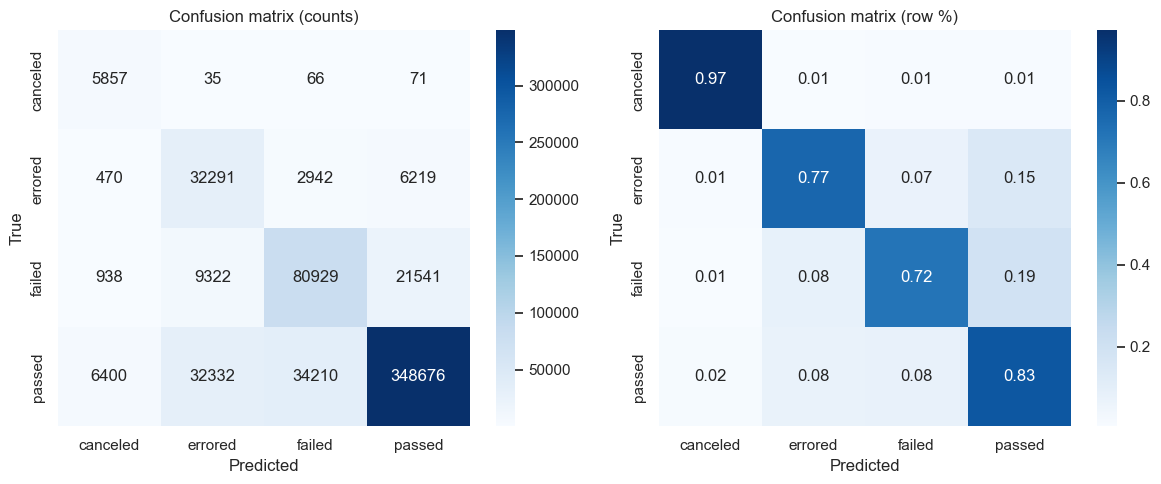

In [47]:
# Confusion matrix (counts)
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion matrix (counts)")
axes[0].set_ylabel("True")
axes[0].set_xlabel("Predicted")
# Percentages (row-normalized)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_pct, annot=True, fmt=".2f", xticklabels=class_names, yticklabels=class_names, ax=axes[1], cmap="Blues")
axes[1].set_title("Confusion matrix (row %)")
axes[1].set_ylabel("True")
axes[1].set_xlabel("Predicted")
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "03_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### Feature importance

Bar chart of XGBoost's built-in feature importance (gain) so we see which features the model relies on most.

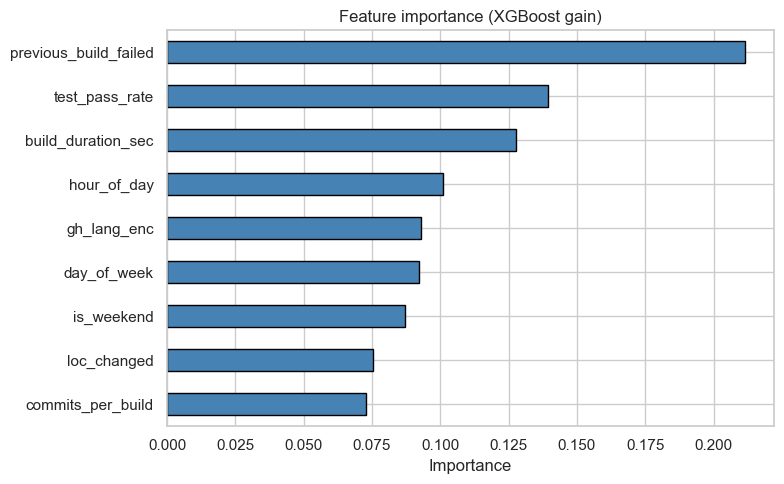

In [48]:
imp = best_model.feature_importances_
fi = pd.Series(imp, index=feature_list).sort_values(ascending=True)
fi.plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Feature importance (XGBoost gain)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "03_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

### Learning curves

Training and validation performance as more data is added. This helps assess whether we are underfitting or could benefit from more data.

Learning curve: 6 train sizes × 3 folds = 18 fits (n_jobs=-1, verbose=2).
Running learning curve...
[learning_curve] Training set sizes: [ 181159  507246  833333 1159420 1485507 1811594]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[CV] END .................................................... total time= 2.5min
[CV] END .................................................... total time= 2.6min
[CV] END .................................................... total time= 5.4min
[CV] END .................................................... total time= 5.5min
[CV] END .................................................... total time= 6.1min
[CV] END .................................................... total time= 6.2min
[CV] END .................................................... total time= 2.3min
[CV] END .................................................... total time= 7.7min
[CV] END .................................................... total time= 7.8min


[Parallel(n_jobs=-1)]: Done   9 out of  18 | elapsed: 11.2min remaining: 11.2min


[CV] END .................................................... total time= 4.9min
[CV] END .................................................... total time= 9.8min
[CV] END .................................................... total time= 5.3min
[CV] END .................................................... total time= 9.3min
[CV] END .................................................... total time=11.3min
[CV] END .................................................... total time= 6.5min
[CV] END .................................................... total time=10.7min
[CV] END .................................................... total time= 7.8min
[CV] END .................................................... total time= 8.1min
Learning curve complete.


[Parallel(n_jobs=-1)]: Done  18 out of  18 | elapsed: 23.0min finished


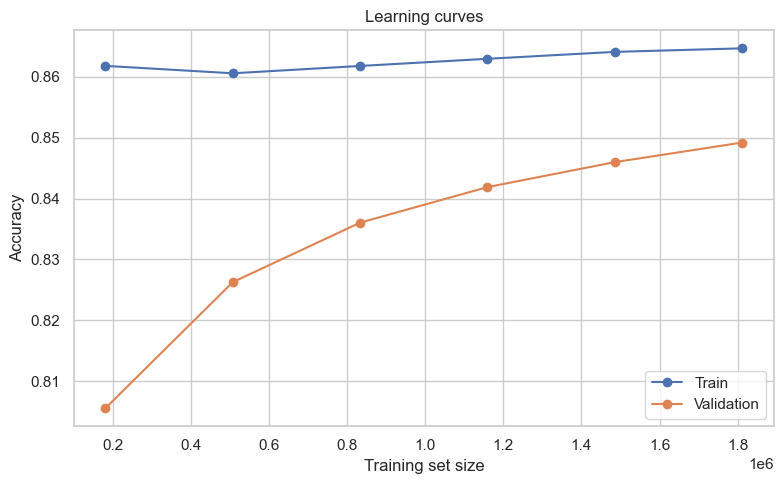

In [49]:
# learning_curve clones the estimator and calls fit(X, y) only — no eval_set.
# So use a model *without* early_stopping_rounds to avoid "Must have at least 1 validation dataset".
train_size_ticks = 6  # 0.1, 0.2, ..., 1.0
lc_fits = train_size_ticks * 3
print(f"Learning curve: {train_size_ticks} train sizes × 3 folds = {lc_fits} fits (n_jobs=-1, verbose=2).")
print("Running learning curve...")
lc_model = xgb.XGBClassifier(
    n_estimators=n_est,
    objective="multi:softprob",
    num_class=len(class_names),
    random_state=42,
    eval_metric="mlogloss",
    **best_params_final,
    **xgb_device_kw,
)
train_sizes, train_scores, val_scores = learning_curve(
    lc_model, X_train, y_train, cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6),
    verbose=2,
)
print("Learning curve complete.")
plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Validation")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "03_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### Save model

Save the best model and test metrics so Notebook 4 (SHAP) and the dashboard can load them without retraining.

In [50]:
joblib.dump(best_model, MODELS_DIR / "build_failure_model.pkl")
metrics = {"accuracy": float(acc_test), "f1_weighted": float(f1_test), "class_names": class_names}
joblib.dump(metrics, MODELS_DIR / "metrics.joblib")
print("Saved build_failure_model.pkl and metrics.joblib")

Saved build_failure_model.pkl and metrics.joblib
